# 🎬 IMDb Movie Review Sentiment Analysis using Machine Learning

This project builds a machine learning model to classify IMDb movie reviews as **Positive** or **Negative** using Natural Language Processing (NLP). The workflow includes data preprocessing, exploratory data analysis (EDA), feature extraction using TF-IDF, model training with Logistic Regression, and performance evaluation.

## 📚 Import Libraries

Import all the required libraries for data manipulation, visualization, natural language processing, and machine learning.

In [8]:
#Libraries
# Data Manipulation
import pandas as pd
import numpy as np
import os # Added for path manipulation

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Natural Language Processing
import nltk
from nltk.corpus import stopwords

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Trained Model
import joblib

# Download Stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 📂 Load Dataset

Load the IMDb Movie Reviews dataset into a pandas DataFrame and preview the data.

In [2]:
#verify

print("=" * 60)
print("✅ All required libraries imported successfully!")
print("=" * 60)

✅ All required libraries imported successfully!


In [9]:
#Dataset
df = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"), sep=',', quotechar='"')

In [10]:
#DISPLAYING THE FIRST FIVE RECORDS

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
# DATASET INFORMATION

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## 🔍 Exploratory Data Analysis (EDA)

Analyze the dataset by examining its structure, missing values, duplicates, review lengths, and sentiment distribution.

In [12]:
#  DATASET DIMENSIONS#
# #EDA #Duplicates

print(f"Duplicate Records : {df.duplicated().sum()}")

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Duplicate Records : 418
Number of Rows    : 50000
Number of Columns : 2


In [13]:
#EDA #MissingValues

df.isnull().sum()

,0
review,0
sentiment,0


In [14]:
# #EDA #Duplicates

print(f"Duplicate Records : {df.duplicated().sum()}")

Duplicate Records : 418


In [15]:
# #EDA #Statistics

df.describe(include='all')

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [16]:
# ==============================================================================
# 📊 SENTIMENT DISTRIBUTION
# ==============================================================================
# #Visualization
# ==============================================================================

print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


/tmp/ipykernel_840/1418776768.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


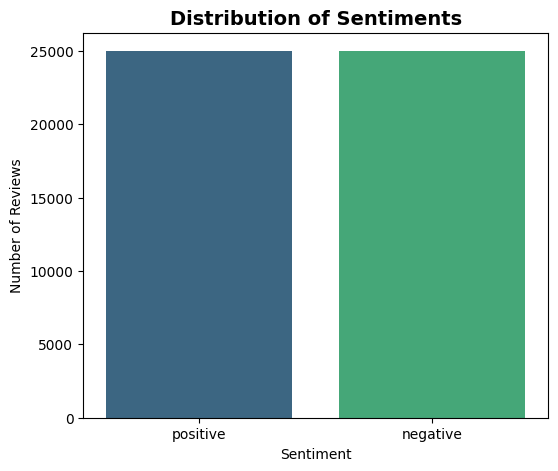

In [17]:
# ==============================================================================
# 📈 VISUALIZING SENTIMENT DISTRIBUTION
# ==============================================================================
# #Visualization
# ==============================================================================

plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="sentiment",
    palette="viridis"
)

plt.title("Distribution of Sentiments", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [18]:
# ==============================================================================
# 📏 REVIEW LENGTH ANALYSIS
# ==============================================================================
# #FeatureEngineering
# ==============================================================================

df["review_length"] = df["review"].apply(len)

df["review_length"].head()

,review_length
0,1761
1,998
2,926
3,748
4,1317


In [19]:
# ==============================================================================
# 📊 REVIEW LENGTH STATISTICS
# ==============================================================================
# #Statistics
# ==============================================================================

df["review_length"].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


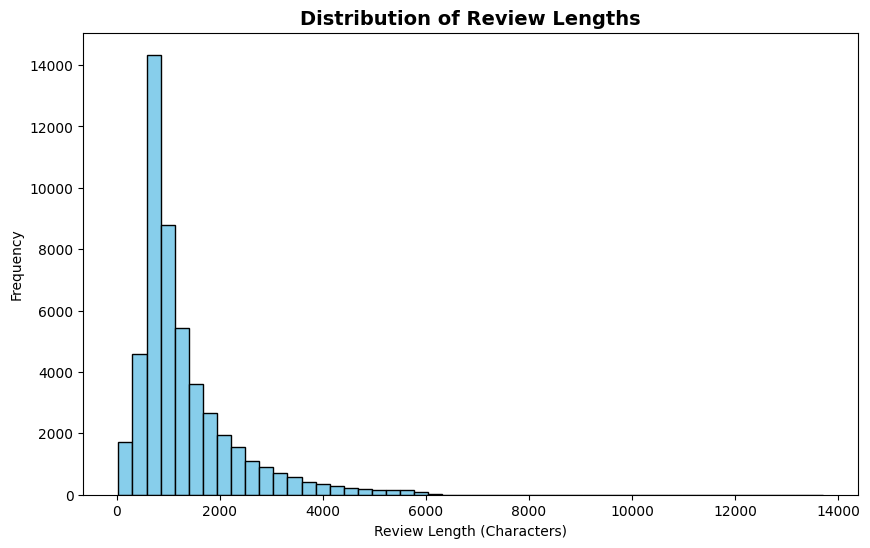

In [20]:
# ==============================================================================
# 📉 DISTRIBUTION OF REVIEW LENGTHS
# ==============================================================================
# #Visualization
# ==============================================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["review_length"],
    bins=50,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Review Lengths", fontsize=14, fontweight="bold")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_840/230342922.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


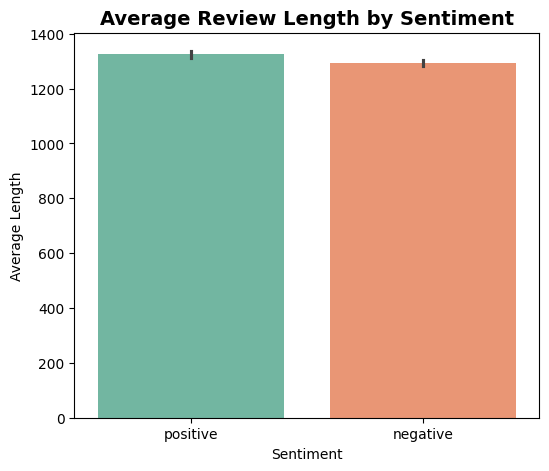

In [21]:
# ==============================================================================
# 📊 AVERAGE REVIEW LENGTH BY SENTIMENT
# ==============================================================================
# #Visualization
# ==============================================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="sentiment",
    y="review_length",
    palette="Set2"
)

plt.title("Average Review Length by Sentiment", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Average Length")

plt.show()

In [22]:
# ==============================================================================
# ⚖️ CLASS BALANCE CHECK
# ==============================================================================
# #EDA
# ==============================================================================

positive_reviews = len(df[df["sentiment"] == "positive"])
negative_reviews = len(df[df["sentiment"] == "negative"])

print(f"Positive Reviews : {positive_reviews}")
print(f"Negative Reviews : {negative_reviews}")

Positive Reviews : 25000
Negative Reviews : 25000


In [23]:
# ==============================================================================
# 📝 EDA SUMMARY
# ==============================================================================
# #Summary
# ==============================================================================

print("=" * 65)
print("Dataset successfully explored.")
print("✔ No missing values detected.")
print("✔ Dataset is balanced.")
print("✔ Review lengths vary significantly.")
print("✔ Ready for text preprocessing.")
print("=" * 65)

Dataset successfully explored.
✔ No missing values detected.
✔ Dataset is balanced.
✔ Review lengths vary significantly.
✔ Ready for text preprocessing.


In [24]:
# ==============================================================================
# 📚 IMPORTING NLP COMPONENTS
# ==============================================================================
# #Preprocessing
# ==============================================================================

from nltk.corpus import stopwords

# English Stopwords
stop_words = set(stopwords.words("english"))

## 🧹 Text Preprocessing

Clean the text by removing HTML tags, URLs, punctuation, numbers, stopwords, and converting all text to lowercase.

In [25]:
# ==============================================================================
# 🧹 TEXT CLEANING FUNCTION
# ==============================================================================
# #Cleaning
# ==============================================================================

def clean_text(text):
    """
    Cleans the input text by performing:
    1. Lowercase conversion
    2. HTML tag removal
    3. URL removal
    4. Punctuation removal
    5. Number removal
    6. Extra whitespace removal
    """

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [26]:
# ==============================================================================
# 🧼 APPLYING TEXT CLEANING
# ==============================================================================
# #Cleaning
# ==============================================================================

df["clean_review"] = df["review"].apply(clean_text)

## ✨ Feature Engineering

Convert cleaned text into numerical features using the TF-IDF Vectorizer for machine learning.

In [27]:
# ==============================================================================
# 👀 ORIGINAL VS CLEANED REVIEW
# ==============================================================================
# #Preview
# ==============================================================================

print("Original Review:\n")
print(df["review"][0])

print("\n" + "="*80 + "\n")

print("Cleaned Review:\n")
print(df["clean_review"][0])

Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [28]:
# ==============================================================================
# 🚫 REMOVING STOPWORDS
# ==============================================================================
# #Stopwords
# ==============================================================================

def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [29]:
# ==============================================================================
# ✨ APPLYING STOPWORD REMOVAL
# ==============================================================================
# #Stopwords
# ==============================================================================

df["clean_review"] = df["clean_review"].apply(remove_stopwords)

In [30]:
# ==============================================================================
# 📄 CLEANED DATASET PREVIEW
# ==============================================================================
# #Preview
# ==============================================================================

df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


In [31]:
# ==============================================================================
# 🏷️ ENCODING SENTIMENT LABELS
# ==============================================================================
# #Encoding
# ==============================================================================

df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.head()

,review,sentiment,review_length,clean_review
0,One of the other reviewers has mentioned that ...,1,1761,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,1,998,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,926,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,748,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,petter matteis love time money visually stunni...


In [34]:
# ==============================================================================
# ✅ VERIFYING LABEL ENCODING
# ==============================================================================
# #Encoding
# ==============================================================================

print(df["sentiment"].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


In [35]:
# ==============================================================================
# 📋 FINAL DATASET INFORMATION
# ==============================================================================
# #Verification
# ==============================================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   review         50000 non-null  object
 1   sentiment      50000 non-null  int64 
 2   review_length  50000 non-null  int64 
 3   clean_review   50000 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.5+ MB


In [36]:
# ==============================================================================
# 🎯 DEFINING FEATURES AND TARGET VARIABLE
# ==============================================================================
# #Features
# ==============================================================================

X = df["clean_review"]
y = df["sentiment"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (50000,)
Target Shape   : (50000,)


## 🤖 Model Training

Train a Logistic Regression classifier using the transformed TF-IDF features.

In [37]:
# ==============================================================================
# ✂️ TRAIN-TEST SPLIT
# ==============================================================================
# #TrainTestSplit
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

Training Samples : 40000
Testing Samples  : 10000


In [38]:
# ==============================================================================
# 🔤 TF-IDF FEATURE EXTRACTION
# ==============================================================================
# #TFIDF
# ==============================================================================

tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Shape :", X_train_tfidf.shape)
print("Testing Shape  :", X_test_tfidf.shape)

Training Shape : (40000, 5000)
Testing Shape  : (10000, 5000)


In [39]:
# ==============================================================================
# 🤖 TRAINING LOGISTIC REGRESSION MODEL
# ==============================================================================
# #Training
# ==============================================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [40]:
# ==============================================================================
# 🔮 MAKING PREDICTIONS
# ==============================================================================
# #Prediction
# ==============================================================================

y_pred = model.predict(X_test_tfidf)

print("Predictions completed successfully!")

Predictions completed successfully!


## 📊 Model Evaluation

Evaluate the trained model using accuracy, precision, recall, F1-score, confusion matrix, and classification report.

In [41]:
# ==============================================================================
# 📊 MODEL ACCURACY
# ==============================================================================
# #Evaluation
# ==============================================================================

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy : {accuracy:.4f}")
print(f"Accuracy (%)   : {accuracy * 100:.2f}%")

Model Accuracy : 0.8888
Accuracy (%)   : 88.88%


In [42]:
# ==============================================================================
# 📈 PERFORMANCE METRICS
# ==============================================================================
# #Evaluation
# ==============================================================================

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.8815
Recall    : 0.8984
F1 Score  : 0.8899


In [43]:
# ==============================================================================
# 📋 CLASSIFICATION REPORT
# ==============================================================================
# #ClassificationReport
# ==============================================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



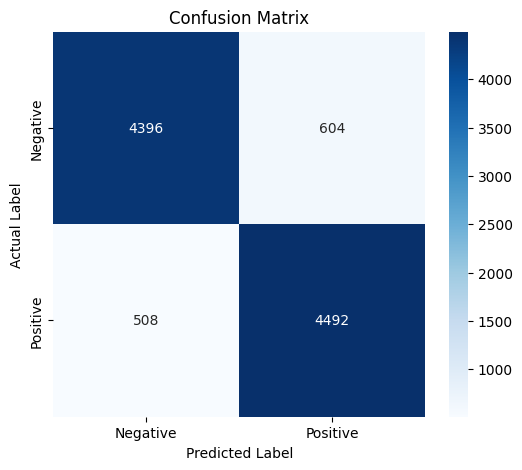

In [44]:
# ==============================================================================
# 📉 CONFUSION MATRIX
# ==============================================================================
# #ConfusionMatrix
# ==============================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 💾 Save Model

Save the trained model and TF-IDF vectorizer for future predictions.

In [45]:
# ==============================================================================
# 💾 SAVING THE TRAINED MODEL
# ==============================================================================
# #ModelSaving
# ==============================================================================

joblib.dump(model, "sentiment_model.pkl")

print("✅ Logistic Regression model saved successfully!")

✅ Logistic Regression model saved successfully!


In [46]:
# ==============================================================================
# 💾 SAVING THE TF-IDF VECTORIZER
# ==============================================================================
# #ModelSaving
# ==============================================================================

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("✅ TF-IDF Vectorizer saved successfully!")

✅ TF-IDF Vectorizer saved successfully!


In [47]:
# ==============================================================================
# 📂 LOADING SAVED MODEL
# ==============================================================================
# #ModelLoading
# ==============================================================================

loaded_model = joblib.load("sentiment_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("✅ Saved files loaded successfully!")

✅ Saved files loaded successfully!


In [48]:
# ==============================================================================
# ✨ CUSTOM SENTIMENT PREDICTION
# ==============================================================================
# #Inference
# ==============================================================================

def predict_sentiment(review):
    """
    Predicts whether a movie review is Positive or Negative.
    """

    # Clean the review
    cleaned_review = clean_text(review)
    cleaned_review = remove_stopwords(cleaned_review)

    # Convert to TF-IDF features
    review_vector = loaded_vectorizer.transform([cleaned_review])

    # Predict sentiment
    prediction = loaded_model.predict(review_vector)[0]

    if prediction == 1:
        return "😊 Positive Review"
    else:
        return "😞 Negative Review"

## 🎯 Test Custom Review

Use the saved model to predict the sentiment of new movie reviews entered by the user.

In [49]:
# ==============================================================================
# 🧪 TESTING SAMPLE REVIEWS
# ==============================================================================
# #Testing
# ==============================================================================

sample_reviews = [
    "This movie was absolutely fantastic. I loved every minute of it!",
    "Worst movie I have ever watched. Total waste of time.",
    "The acting was decent but the story was boring.",
    "Amazing cinematography and brilliant performances."
]

for review in sample_reviews:
    print(f"\nReview : {review}")
    print(f"Prediction : {predict_sentiment(review)}")
    print("-" * 80)


Review : This movie was absolutely fantastic. I loved every minute of it!
Prediction : 😊 Positive Review
--------------------------------------------------------------------------------

Review : Worst movie I have ever watched. Total waste of time.
Prediction : 😞 Negative Review
--------------------------------------------------------------------------------

Review : The acting was decent but the story was boring.
Prediction : 😞 Negative Review
--------------------------------------------------------------------------------

Review : Amazing cinematography and brilliant performances.
Prediction : 😊 Positive Review
--------------------------------------------------------------------------------


In [50]:
# ==============================================================================
# 💬 PREDICT YOUR OWN REVIEW
# ==============================================================================
# #Inference
# ==============================================================================

user_review = input("Enter a movie review:\n\n")

print("\nPrediction:", predict_sentiment(user_review))

Enter a movie review:

4

Prediction: 😞 Negative Review


In [59]:
# ==============================================================================
# 🎬 INTERACTIVE SENTIMENT ANALYZER
# ==============================================================================
# #UI
# ==============================================================================

import ipywidgets as widgets
from IPython.display import display, Markdown

# Create widgets
review_box = widgets.Textarea(
    value="",
    placeholder="Type your movie review here...",
    description="Review:",
    layout=widgets.Layout(width="100%", height="150px")
)

predict_button = widgets.Button(
    description="Predict Sentiment",
    button_style="success",
    icon="check"
)

output = widgets.Output()

# Prediction function
def on_predict_clicked(b):
    output.clear_output()

    review = review_box.value.strip()

    with output:
        if review == "":
            display(Markdown("### ⚠️ Please enter a movie review."))
        else:
            prediction = predict_sentiment(review)

            if "Positive" in prediction:
                display(Markdown(f"## 😊 **{prediction}**"))
            else:
                display(Markdown(f"## 😞 **{prediction}**"))

# Button click event
predict_button.on_click(on_predict_clicked)

# Display UI
display(Markdown("# 🎬 Movie Review Sentiment Analyzer"))
display(review_box)
display(predict_button)
display(output)

# 🎬 Movie Review Sentiment Analyzer

Textarea(value='', description='Review:', layout=Layout(height='150px', width='100%'), placeholder='Type your …

Button(button_style='success', description='Predict Sentiment', icon='check', style=ButtonStyle())

Output()

## ✅ Conclusion

The sentiment analysis model successfully classifies IMDb movie reviews with high accuracy. This project demonstrates an end-to-end NLP pipeline, including preprocessing, feature extraction, model training, evaluation, and inference.